In [3]:
#importing 
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt 
plt.figure(figsize=(8, 5))

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

In [4]:
#loading the data
df=pd.read_csv('../data/Airline_Delay_Cause.csv')
df.head()

,year,month,carrier,carrier_name,airport,airport_name,arr_flights,arr_del15,carrier_ct,weather_ct,...,security_ct,late_aircraft_ct,arr_cancelled,arr_diverted,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
0,2023,8,9E,Endeavor Air Inc.,ABE,"Allentown/Bethlehem/Easton, PA: Lehigh Valley ...",89.0,13.0,2.25,1.60,...,0.0,5.99,2.0,1.0,1375.0,71.0,761.0,118.0,0.0,425.0
1,2023,8,9E,Endeavor Air Inc.,ABY,"Albany, GA: Southwest Georgia Regional",62.0,10.0,1.97,0.04,...,0.0,7.42,0.0,1.0,799.0,218.0,1.0,62.0,0.0,518.0
2,2023,8,9E,Endeavor Air Inc.,AEX,"Alexandria, LA: Alexandria International",62.0,10.0,2.73,1.18,...,0.0,4.28,1.0,0.0,766.0,56.0,188.0,78.0,0.0,444.0
3,2023,8,9E,Endeavor Air Inc.,AGS,"Augusta, GA: Augusta Regional at Bush Field",66.0,12.0,3.69,2.27,...,0.0,1.57,1.0,1.0,1397.0,471.0,320.0,388.0,0.0,218.0
4,2023,8,9E,Endeavor Air Inc.,ALB,"Albany, NY: Albany International",92.0,22.0,7.76,0.00,...,0.0,11.28,2.0,0.0,1530.0,628.0,0.0,134.0,0.0,768.0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 171666 entries, 0 to 171665
Data columns (total 21 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   year                 171666 non-null  int64  
 1   month                171666 non-null  int64  
 2   carrier              171666 non-null  object 
 3   carrier_name         171666 non-null  object 
 4   airport              171666 non-null  object 
 5   airport_name         171666 non-null  object 
 6   arr_flights          171426 non-null  float64
 7   arr_del15            171223 non-null  float64
 8   carrier_ct           171426 non-null  float64
 9   weather_ct           171426 non-null  float64
 10  nas_ct               171426 non-null  float64
 11  security_ct          171426 non-null  float64
 12  late_aircraft_ct     171426 non-null  float64
 13  arr_cancelled        171426 non-null  float64
 14  arr_diverted         171426 non-null  float64
 15  arr_delay        

In [6]:
df.describe()

,year,month,arr_flights,arr_del15,carrier_ct,weather_ct,nas_ct,security_ct,late_aircraft_ct,arr_cancelled,arr_diverted,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
count,171666.000000,171666.000000,171426.000000,171223.000000,171426.000000,171426.000000,171426.000000,171426.000000,171426.000000,171426.000000,171426.000000,171426.00000,171426.000000,171426.000000,171426.000000,171426.000000,171426.000000
mean,2018.551361,6.493633,362.528467,66.434387,20.796615,2.250347,19.381147,0.157096,23.770554,7.530497,0.863387,4239.48733,1437.185124,222.563497,920.651704,7.382725,1651.700063
std,2.890006,3.440908,992.894662,179.540694,50.315176,7.314252,61.675244,0.717405,72.393477,43.654880,3.772853,12618.56605,4215.677812,821.086511,3423.509335,41.779985,5221.878385
min,2013.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2016.000000,4.000000,50.000000,6.000000,2.160000,0.000000,1.000000,0.000000,1.230000,0.000000,0.000000,335.00000,110.000000,0.000000,34.000000,0.000000,65.000000
50%,2019.000000,7.000000,100.000000,17.000000,6.400000,0.400000,3.910000,0.000000,5.000000,1.000000,0.000000,1018.00000,375.000000,18.000000,146.000000,0.000000,320.000000
75%,2021.000000,9.000000,250.000000,47.000000,17.260000,1.860000,11.710000,0.000000,15.260000,4.000000,1.000000,2884.00000,1109.000000,146.000000,477.000000,0.000000,1070.000000
max,2023.000000,12.000000,21977.000000,4176.000000,1293.910000,266.420000,1884.420000,58.690000,2069.070000,4951.000000,197.000000,438783.00000,196944.000000,31960.000000,112018.000000,3760.000000,227959.000000


In [17]:
#checking for duplicate values
df.duplicated().sum()

np.int64(0)

In [ ]:
#Checking for missing values
df.isnull().sum()


year                     0
month                    0
carrier                  0
carrier_name             0
airport                  0
airport_name             0
arr_flights            240
arr_del15              443
carrier_ct             240
weather_ct             240
nas_ct                 240
security_ct            240
late_aircraft_ct       240
arr_cancelled          240
arr_diverted           240
arr_delay              240
carrier_delay          240
weather_delay          240
nas_delay              240
security_delay         240
late_aircraft_delay    240
dtype: int64

In [8]:
# Check if nulls cluster around specific years/carriers
print(df[df.isnull().any(axis=1)]['year'].value_counts())
print(df[df.isnull().any(axis=1)]['carrier_name'].value_counts())

year
2020    260
2021     25
2014     23
2016     22
2018     20
2019     19
2023     18
2022     16
2017     15
2015     15
2013     10
Name: count, dtype: int64
carrier_name
SkyWest Airlines Inc.           72
Allegiant Air                   63
Delta Air Lines Inc.            56
Mesa Airlines Inc.              37
Endeavor Air Inc.               34
ExpressJet Airlines Inc.        33
Envoy Air                       27
United Air Lines Inc.           26
Republic Airline                25
ExpressJet Airlines LLC         17
Frontier Airlines Inc.          17
Spirit Air Lines                 9
American Airlines Inc.           7
PSA Airlines Inc.                7
JetBlue Airways                  5
Virgin America                   3
Alaska Airlines Inc.             2
Hawaiian Airlines Inc.           1
AirTran Airways Corporation      1
American Eagle Airlines Inc.     1
Name: count, dtype: int64


In [9]:
print(df[df['year'] == 2020].shape)
total_2020 = df[df['year'] == 2020].shape[0]
null_2020 = df[(df['year'] == 2020) & df.isnull().any(axis=1)].shape[0]
print(f"Null % in 2020: {null_2020/total_2020*100:.2f}%")

(18859, 21)
Null % in 2020: 1.38%


By Year: 2020 dominates with 260 nulls ,that's almost certainly COVID-19 impact. Many flights were grounded or had incomplete reporting during that period. The rest are scattered thinly (10–25 rows), which is just random data noise.18,859 rows in 2020 total, and only 1.38% are null and  that's negligible.

By Carrier: SkyWest (72), Allegiant (63), Delta (56) have the most nulls

Since, null count in the data is too low in comparison to that of the dataset size , so it is better to drop those rows will null values in them for better analysis process.


In [10]:
#Dropping the rows with null values
df.dropna(inplace=True)
df.isnull().sum()


year                   0
month                  0
carrier                0
carrier_name           0
airport                0
airport_name           0
arr_flights            0
arr_del15              0
carrier_ct             0
weather_ct             0
nas_ct                 0
security_ct            0
late_aircraft_ct       0
arr_cancelled          0
arr_diverted           0
arr_delay              0
carrier_delay          0
weather_delay          0
nas_delay              0
security_delay         0
late_aircraft_delay    0
dtype: int64

In [11]:
numerical_columns = ['arr_flights', 'arr_del15', 'carrier_ct', 'weather_ct', 'nas_ct', 'security_ct', 'late_aircraft_ct', 'arr_cancelled', 'arr_diverted', 'arr_delay', 'carrier_delay', 'weather_delay', 'nas_delay', 'security_delay', 'late_aircraft_delay']
categorical_columns = ['carrier', 'carrier_name', 'airport', 'airport_name']

In [12]:
# Delay rate: what % of arriving flights were delayed
df['delay_rate'] = df['arr_del15'] / df['arr_flights']

# Cancellation rate
df['cancel_rate'] = df['arr_cancelled'] / df['arr_flights']

# Average delay per delayed flight
df['avg_delay_per_flight'] = df['arr_delay'] / df['arr_del15'].replace(0, np.nan)

# Year-Month as period for time series
df['period'] = pd.to_datetime(df[['year','month']].assign(day=1))

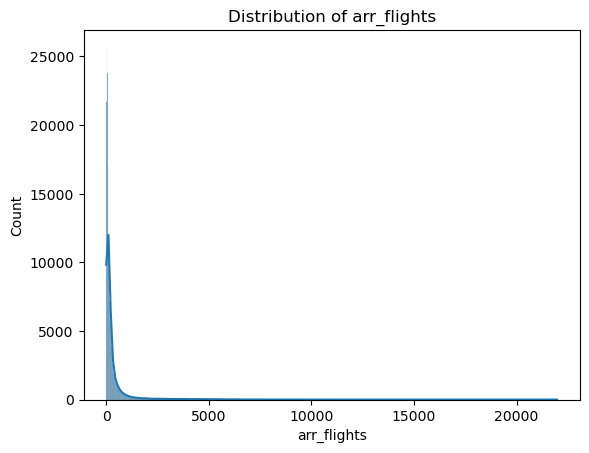

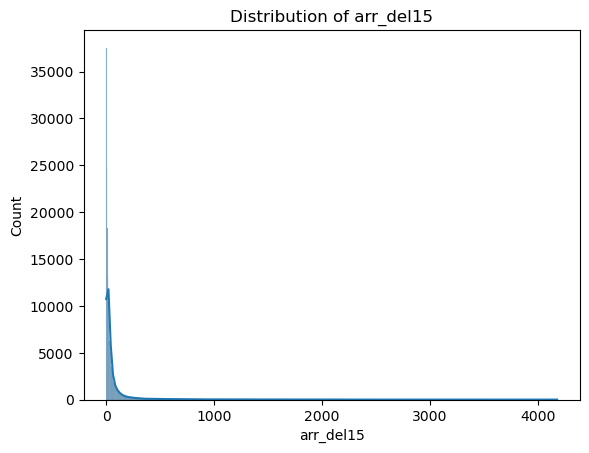

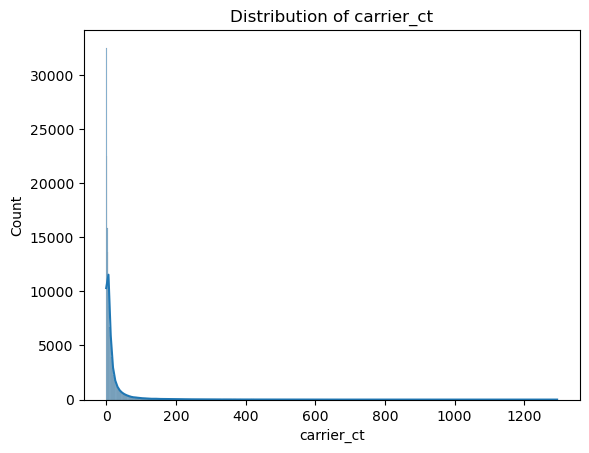

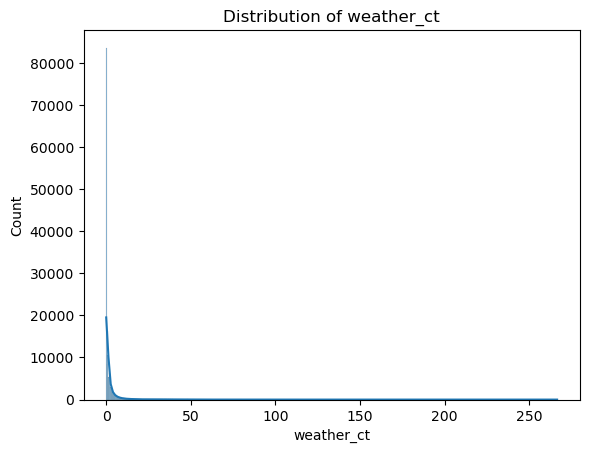

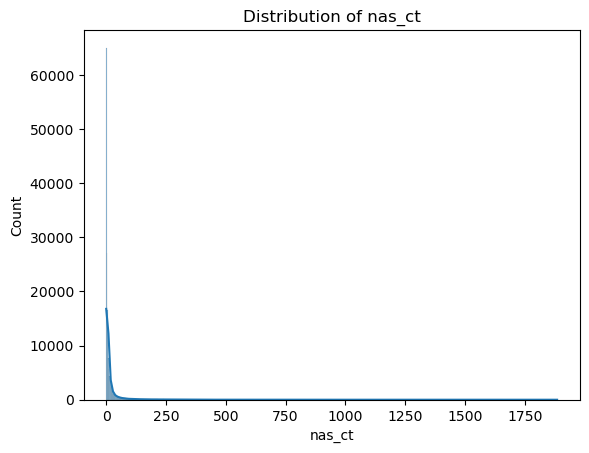

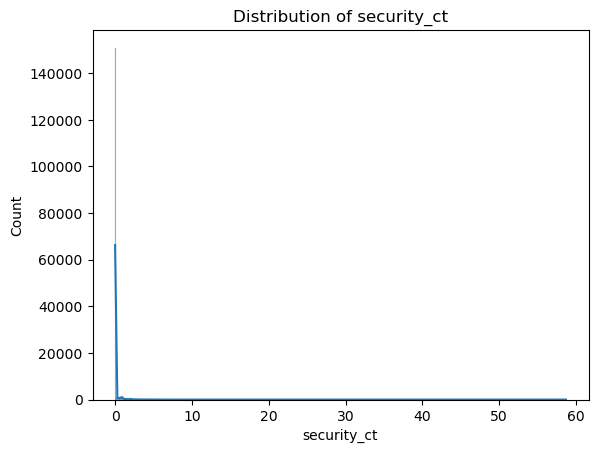

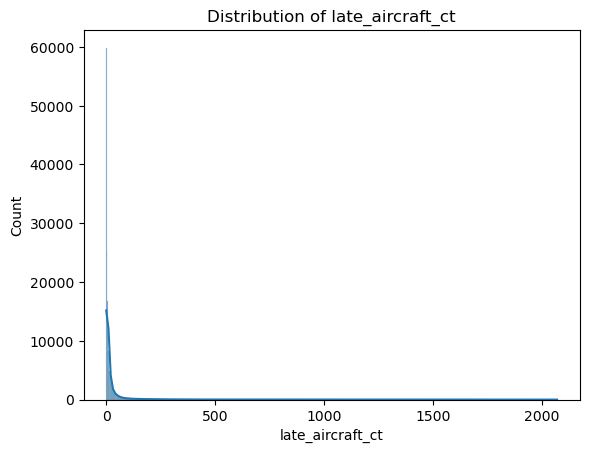

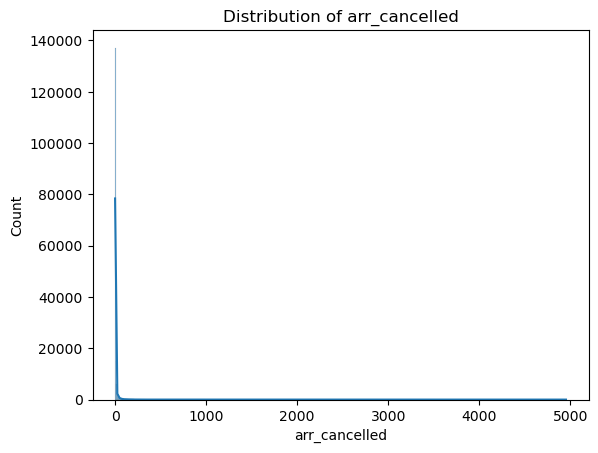

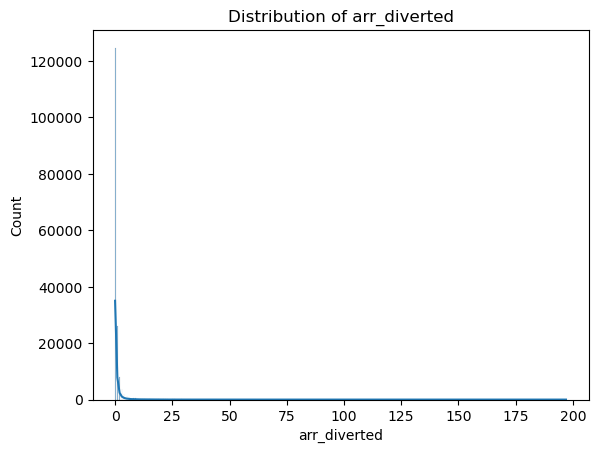

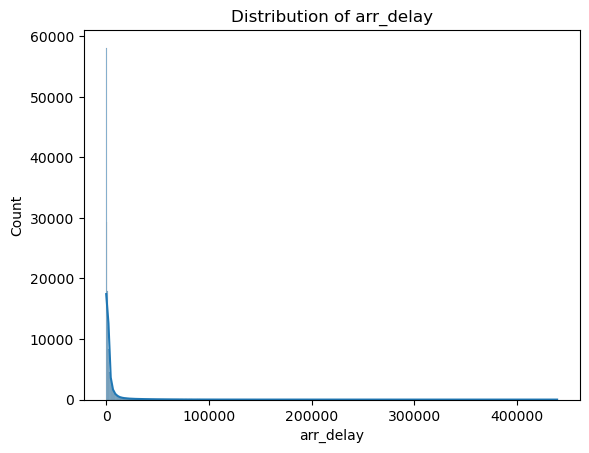

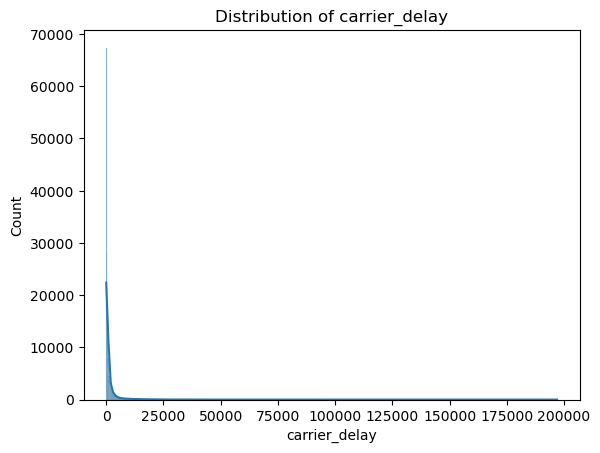

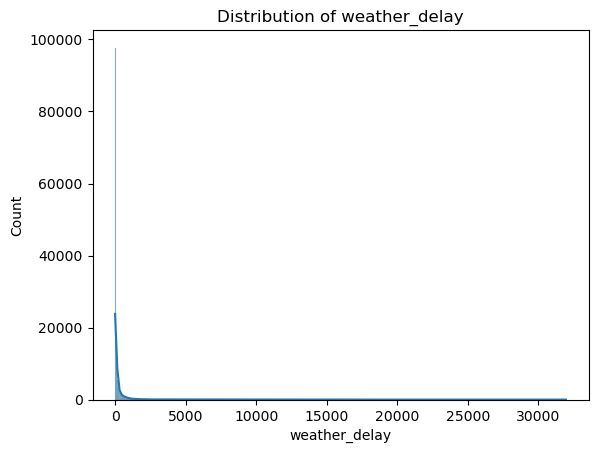

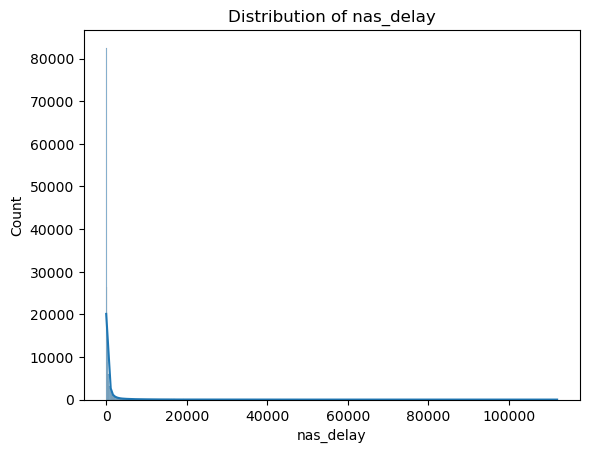

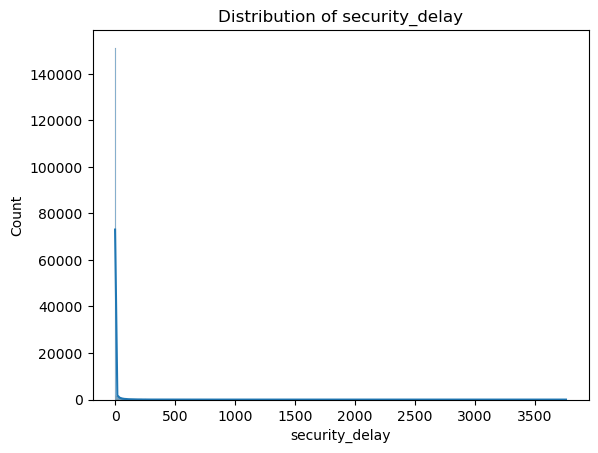

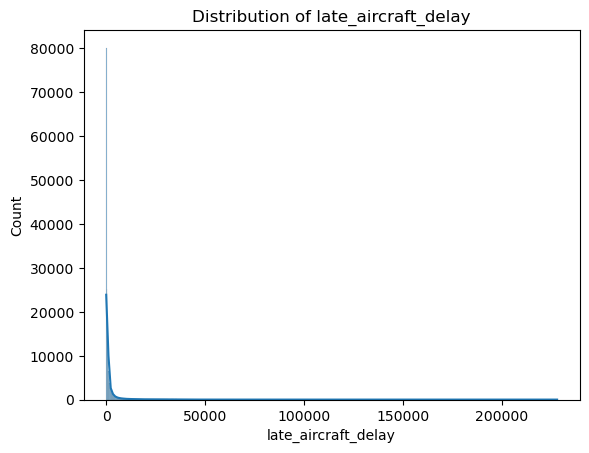

In [15]:
#Distribution in numerical columns
for feature in numerical_columns:
  
    sns.histplot(df[feature], kde=True)
    plt.title(f'Distribution of {feature}')
    plt.show()

Insight:

Columns like carrier_delay, weather_delay, and late_aircraft_delay are heavily positively skewed, it indicates that while most flights experience minimal or no delays, a small percentage of "outlier" flights suffer from extreme disruptions. This "long tail" suggests that average delay statistics are easily inflated by these rare but severe events, making the median a more accurate representation of typical performance than the mean.

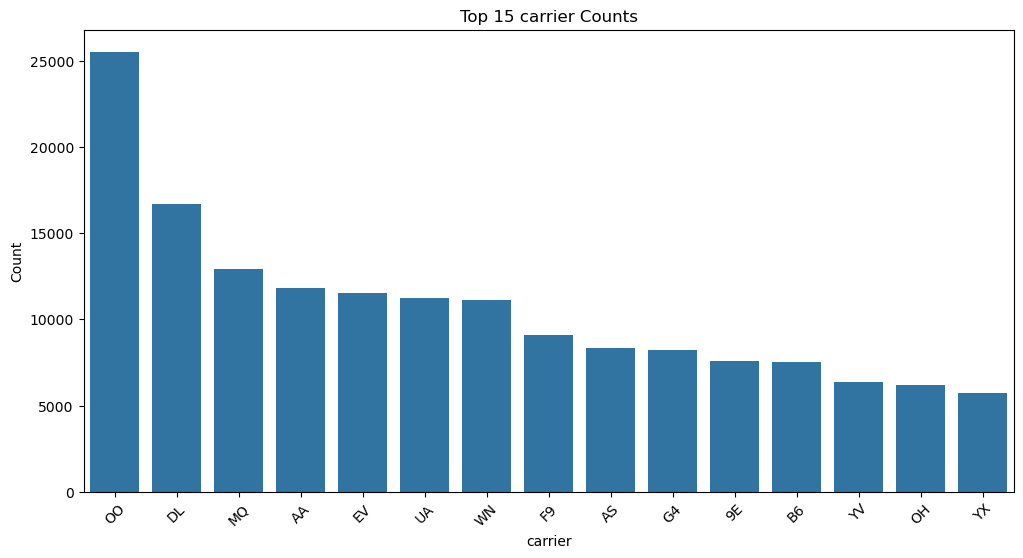

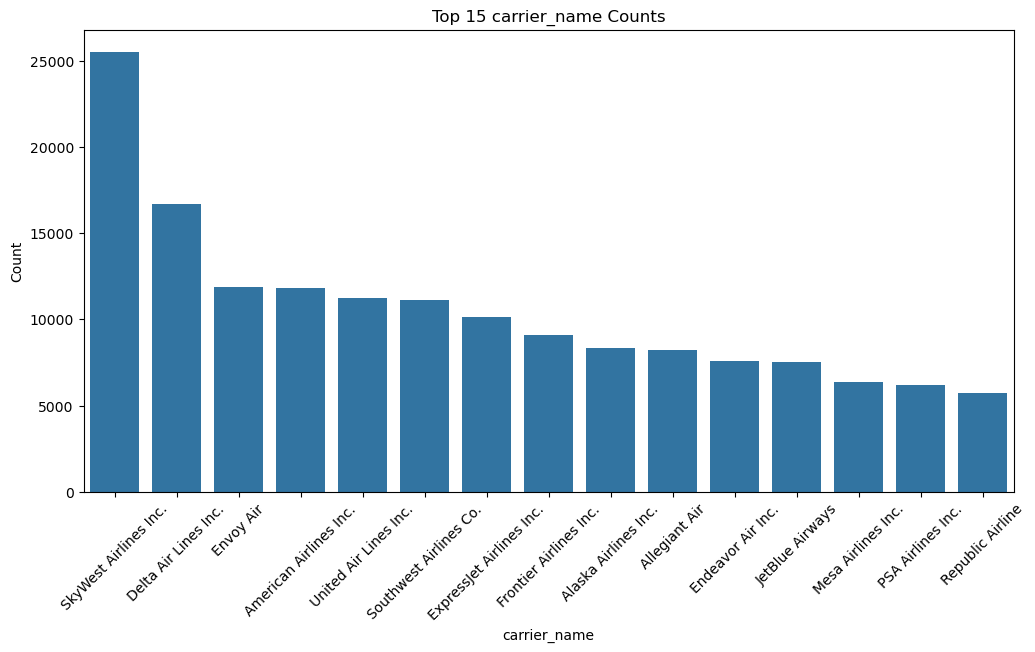

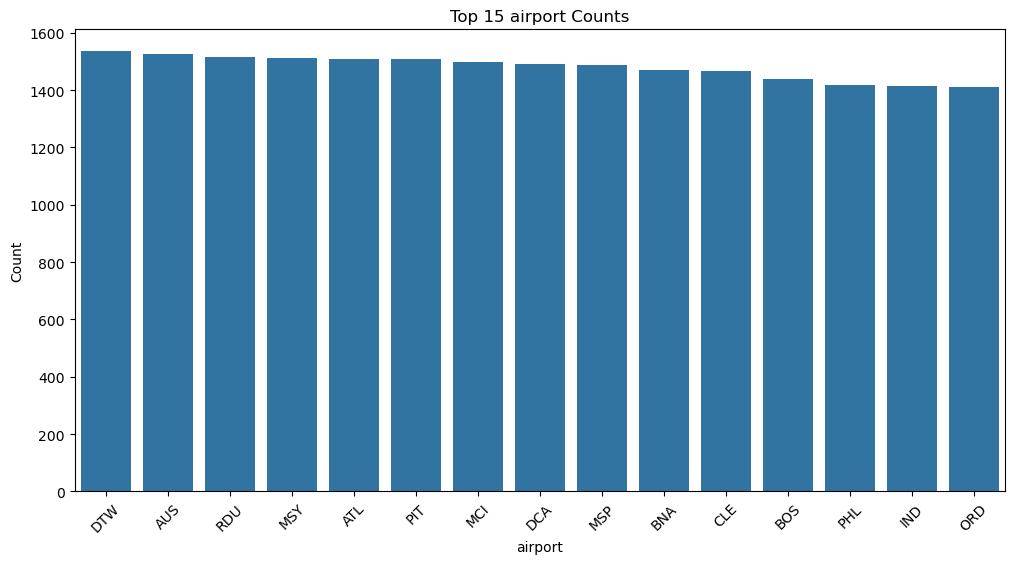

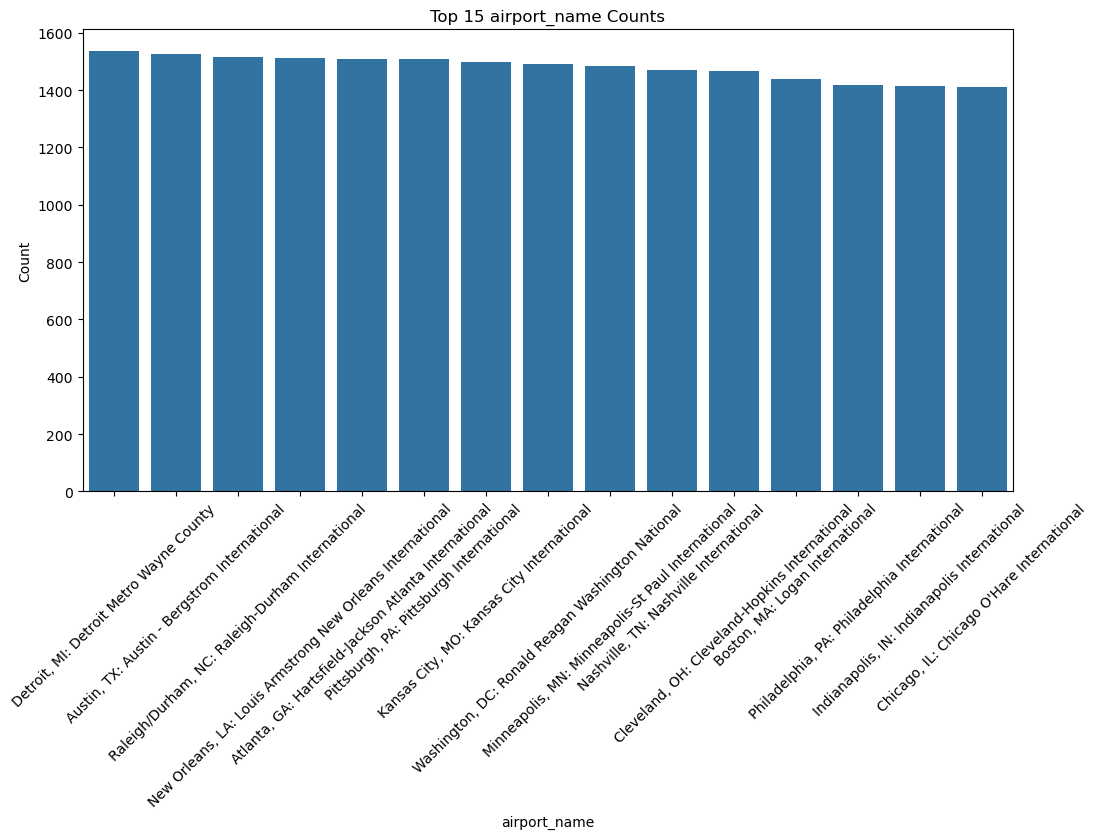

In [16]:
for feature in categorical_columns:
    top_categories = df[feature].value_counts().nlargest(15)
    
    plt.figure(figsize=(12, 6))
    sns.barplot(x=top_categories.index, y=top_categories.values)
    plt.title(f'Top {15} {feature} Counts')
    plt.xlabel(feature)
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.show()

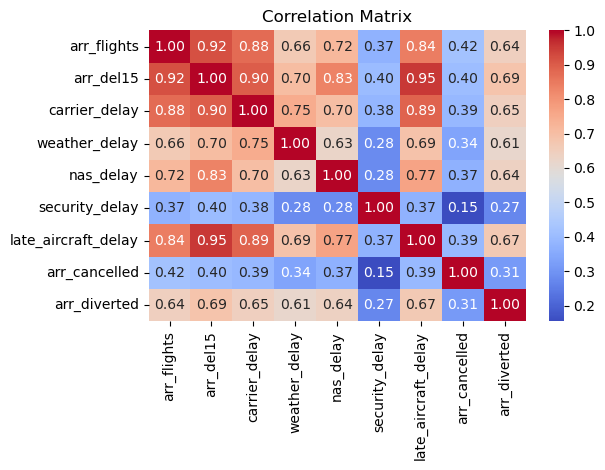

In [30]:
corr_cols = ['arr_flights','arr_del15','carrier_delay','weather_delay',
             'nas_delay','security_delay','late_aircraft_delay','arr_cancelled','arr_diverted']

sns.heatmap(df[corr_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

Insights:
- late_aircraft_delay correlates 0.95 with arr_del15 — the single strongest predictor of whether a flight is delayed. carrier_delay (0.90) and arr_flights (0.92) also correlate strongly with arr_del15 — busier routes have more delays, and carrier-controlled factors are highly predictive.
- security_delay is the outlier — correlates weakly with everything (0.15–0.40).
- arr_cancelled (0.39–0.42) has surprisingly low correlation with delay columns — cancellations and delays are largely independent decisions.
- weather_delay and nas_delay correlate 0.63 with each other — makes sense, since NAS (air traffic control) disruptions are often triggered by weather, creating a partial dependency between the two.

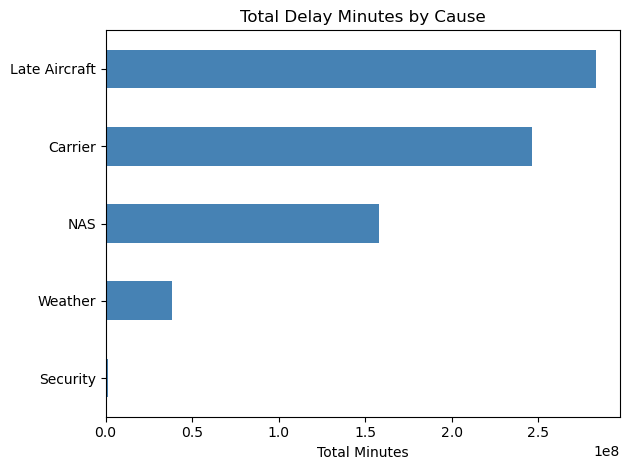

In [20]:
#for understandsing delay cause 
# Total minutes by cause
cause_totals = {
    'Carrier':       df['carrier_delay'].sum(),
    'Weather':       df['weather_delay'].sum(),
    'NAS':           df['nas_delay'].sum(),
    'Security':      df['security_delay'].sum(),
    'Late Aircraft': df['late_aircraft_delay'].sum()
}

pd.Series(cause_totals).sort_values().plot(kind='barh', color='steelblue')
plt.title("Total Delay Minutes by Cause")
plt.xlabel("Total Minutes")
plt.tight_layout()
plt.show()

In [21]:
# Percentage contribution of each cause
cause_df = pd.DataFrame(cause_totals, index=[0]).T
cause_df.columns = ['total']
cause_df['pct'] = cause_df['total'] / cause_df['total'].sum() * 100
print(cause_df.sort_values('pct', ascending=False))

                     total        pct
Late Aircraft  283144335.0  38.959940
Carrier        246370897.0  33.900008
NAS            157823639.0  21.716131
Weather         38153170.0   5.249779
Security         1265591.0   0.174142


Insight:
- The chart reveals that Late Aircraft and Carrier issues are the primary drivers of flight disruptions, accounting for the vast majority of total delay minutes.
- In contrast, Security and Weather contribute significantly less to the overall time lost, suggesting that operational inefficiencies and logistical "knock-on" effects are more impactful than external environmental factors.

C:\Users\Acer\AppData\Local\Temp\ipykernel_90852\1943526864.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_carriers.values, y=top_carriers.index, palette='Reds_r')


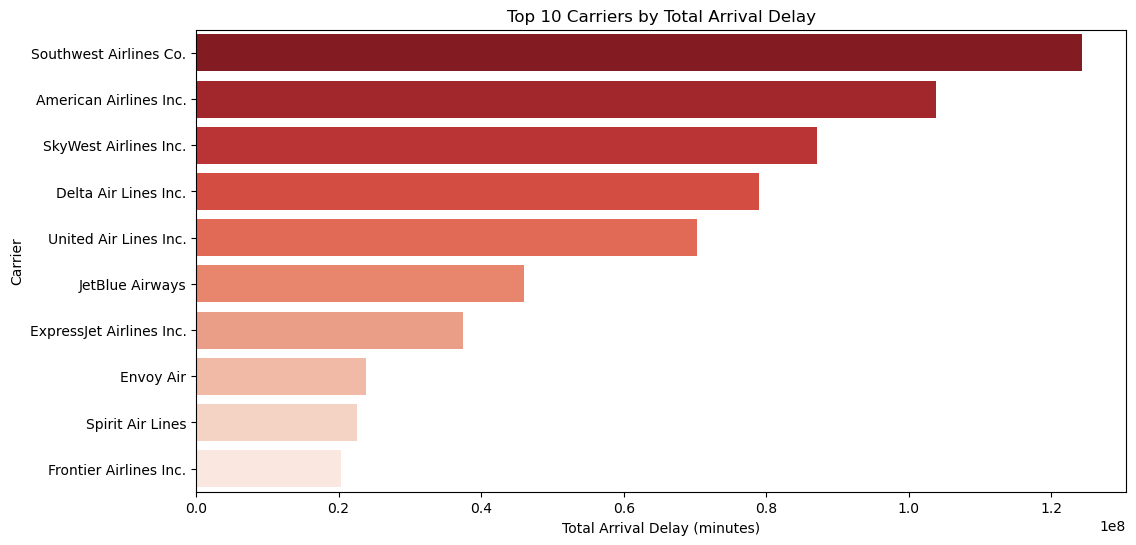

In [22]:
#Checking the worst airports/airlines for delays
# Worst carriers by total arrival delay
top_carriers = df.groupby('carrier_name')['arr_delay'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_carriers.values, y=top_carriers.index, palette='Reds_r')
plt.title("Top 10 Carriers by Total Arrival Delay")
plt.xlabel("Total Arrival Delay (minutes)")
plt.ylabel("Carrier")
plt.show()


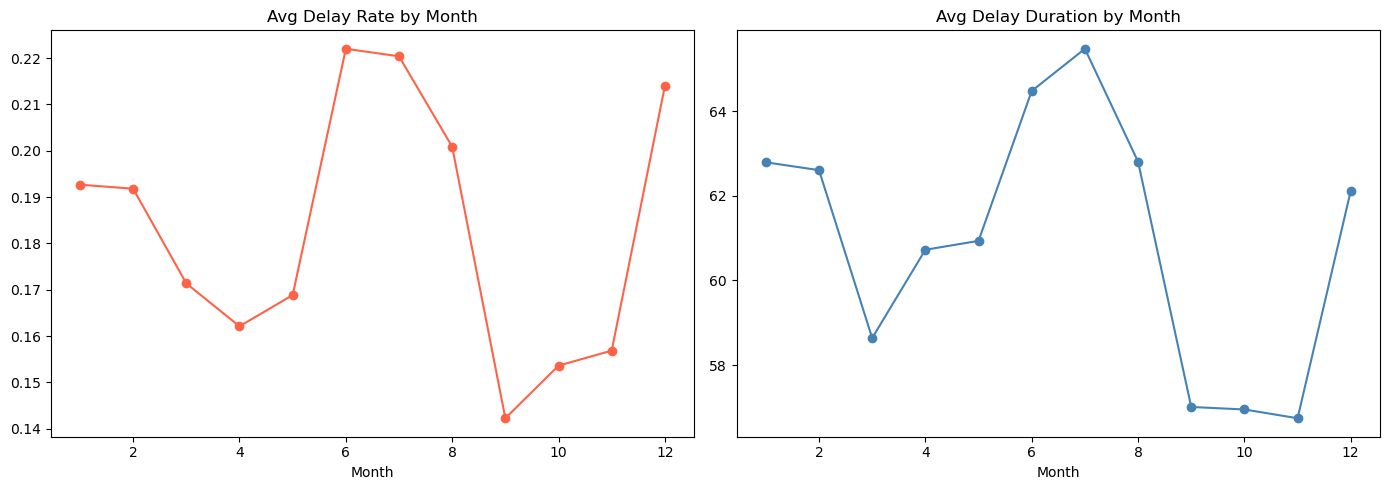

In [26]:
monthly = df.groupby('month').agg(
    delay_rate=('delay_rate','mean'),
    avg_delay=('avg_delay_per_flight','mean')
)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
monthly['delay_rate'].plot(ax=ax[0], marker='o', color='tomato')
ax[0].set_title("Avg Delay Rate by Month"); ax[0].set_xlabel("Month")

monthly['avg_delay'].plot(ax=ax[1], marker='o', color='steelblue')
ax[1].set_title("Avg Delay Duration by Month"); ax[1].set_xlabel("Month")

plt.tight_layout()
plt.show()


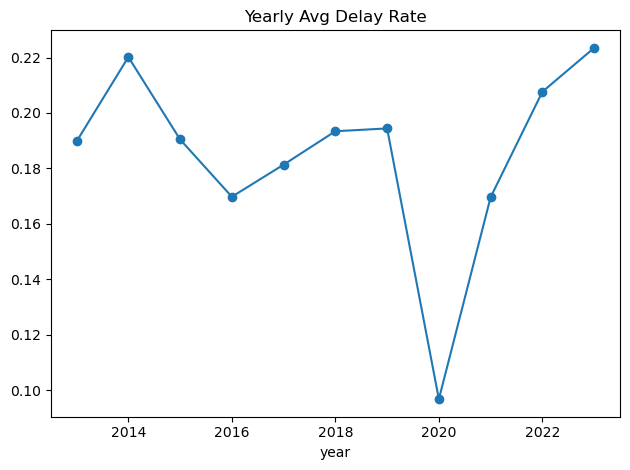

In [27]:
yearly = df.groupby('year')['delay_rate'].mean()
yearly.plot(marker='o')
plt.title("Yearly Avg Delay Rate")
plt.tight_layout()
plt.show()

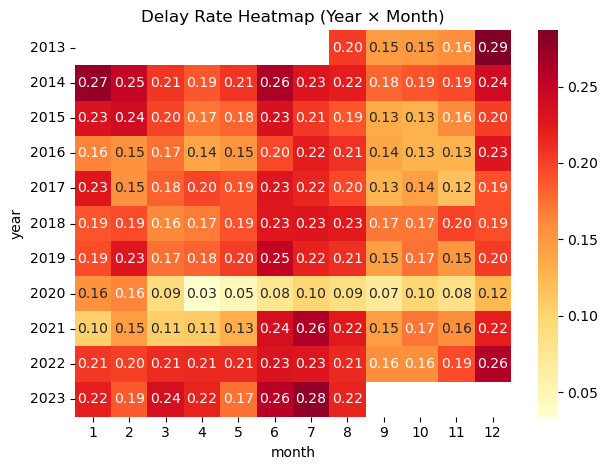

In [28]:
pivot = df.pivot_table(values='delay_rate', index='year', columns='month', aggfunc='mean')
sns.heatmap(pivot, cmap='YlOrRd', annot=True, fmt='.2f')
plt.title("Delay Rate Heatmap (Year × Month)")
plt.tight_layout()
plt.show()

Insights:

- Top 10 Carriers by Total Arrival Delay : Southwest leads with ~125M delay minutes, nearly 20% more than American Airlines (2nd). The top 3 — Southwest, American, SkyWest — account  for a disproportionate share of total delays combined.
- Avg Delay Rate & Duration by Month : 
    - Delay Rate : Clear twin peaks at June–July (~0.22) and December (~0.21), with a sharp valley in September (~0.14) — the best month to fly. This is classic summer travel + holiday season demand surge.
    - Avg Delay Duration : Peaks in July (~65 min) but then drops sharply from September onwards, hitting a low around October–November (~57 min). Interestingly, December has a high delay rate but relatively lower duration — meaning many flights get delayed in December, but they tend to be sh matrixorter delays, possibly because airlines over-buffer schedules during holidays.
- Yearly Avg Delay Rate : The most striking feature is the 2020 COVID crash to ~0.097 — roughly half the normal delay rate. Post-COVID recovery is overshooting pre-COVID levels — 2022 (~0.21) and 2023 (~0.22) are the highest delay rates in the entire dataset, surpassing even 2014's peak of ~0.22. 2016 was historically the best normal year at ~0.17, worth investigating what operational conditions existed then.
- Delay Rate Heatmap (Year × Month): 020 is visually the coldest row — delay rates of 0.03–0.12 across all months confirm the COVID grounding effect.June–July are consistently the darkest columns across almost every year, confirming summer as the structurally worst period regardless of year

# Overall Conclusion

The airline delay dataset reveals a system under persistent and worsening strain. Delays are structurally seasonal — June–July and December are consistently the worst periods across all years, while September–November offer the most reliable on-time performance.

The 2020 COVID dip to a ~0.097 delay rate was a temporary anomaly, and the post-pandemic rebound has actually pushed 2022–2023 to the highest delay rates in the entire dataset (~0.22), suggesting the industry recovered flight volume faster than it recovered operational capacity.

The dominant driver of delays is the late aircraft cascade effect (0.95 correlation with arr_del15), meaning delays are largely self-reinforcing within a single day's operations.

Roughly 3 out of every 4 delay minutes in the US aviation system are caused by factors the airlines themselves control. Weather, the cause most passengers blame, is responsible for only 1 in 20 delay minutes.
 


# Recommendation

Airlines and regulators should prioritize breaking the late aircraft cascade by protecting early morning departure slots with buffer time and reducing aircraft turn times during peak months — since fixing the first delay of the day prevents a chain of downstream ones.

Capacity planning must be urgently recalibrated for the post-COVID era, as scheduling aggressiveness in 2022–2023 has clearly outpaced workforce and infrastructure recovery.

June, July, and December should be treated as high-alert operational periods with pre-positioned resources, proactive crew scheduling, and passenger communication protocols.

SkyWest warrants a focused operational audit given its outsized delay footprint relative to its fleet size.

Finally, since NAS and weather delays are partially correlated, investing in predictive weather-routing technology and closer airline-ATC coordination during storm seasons would yield compounding benefits across both categories simultaneously.

If airlines could reduce Late Aircraft and Carrier delays by even 20%, the system-wide impact would dwarf any investment in weather mitigation technology.